In [2]:
# Import Packages
import os
import re
import sys
import time
import copy
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd

In [3]:
#%load_ext autoreload
#%reload_ext autoreload
#%autoreload 2
#from model_functions import *

%run Model_functions.ipynb

# EMIT FULL BANDS DATA

In [4]:
#EMIT_DATA_CSV         = "../../DATA/AGB_DATA/Merged_Data/EMIT_AGB/AGB_EO_EMIT.csv"
EMIT_DATA_CSV         = "../../DATA/AGB_DATA/Merged_Data/EMIT_AGB/AGB_EMIT_EO_CANOPY.csv"
#EMIT_MISSING_DATA_CSV = "../../DATA/AGB_DATA/Merged_Data/EMIT_AGB/AGB_EO_EMIT_MISSING.csv"

In [5]:
emit_df = pd.read_csv(EMIT_DATA_CSV)
print(emit_df.shape)

(3880, 316)


## DATA PREPROCESSING

### Select feature columns

In [70]:
non_feature_cols = [
    'dataset',             # metadata
    'EMIT_selected_date',  # metadata
    'EMIT_granule',        # metadata
    'start_date',          # metadata
    'end_date',            # metadata
    'capture_start',       # metadata
    'capture_end',         # metadata
    'latitude',            # coordinate
    'longitude',           # coordinate
    'plant_AGB_kg',        # Target variable
    'diameter',            # Allometric
    'height'               # Allometric
]
target = 'plant_AGB_kg'

feature_cols = [c for c in emit_df.columns if c not in non_feature_cols]

X_belige = emit_df[feature_cols]
y_belige = emit_df[target]

X_belige = X_belige.rename({'tandemx_height_m': 'height'}, axis=1)

print(f"Features : {X_belige.columns}")
print(f"Rows     : {len(emit_df)}")

Features : Index(['plot_id', 'species', 'NDVI', 'NDRE1', 'NDRE2', 'NDRE3', 'NBR', 'MSI',
       'EVI', 'CIrededge',
       ...
       'EMIT_R1357', 'EMIT_R1417', 'EMIT_R1424', 'EMIT_R1432', 'EMIT_R1774',
       'EMIT_R1781', 'EMIT_R1789', 'EMIT_R1796', 'simard_height_m', 'height'],
      dtype='object', length=304)
Rows     : 3880


### Handle EMIT columns with NULL data

In [71]:
X_belige = handle_null_columns(X_belige)

Total NULL count           : 17604
Rows with at least one NULL: 1467
Total rows                 : 3880
Percentage                 : 37.8%

NULL count per column in affected rows:
EMIT_R1327    1467
EMIT_R1432    1467
EMIT_R1335    1467
EMIT_R1342    1467
EMIT_R1350    1467
EMIT_R1417    1467
EMIT_R1424    1467
EMIT_R1357    1467
EMIT_R1774    1467
EMIT_R1781    1467
EMIT_R1789    1467
EMIT_R1796    1467
dtype: int64
Dropping 12 columns:
['EMIT_R1327', 'EMIT_R1335', 'EMIT_R1342', 'EMIT_R1350', 'EMIT_R1357', 'EMIT_R1417', 'EMIT_R1424', 'EMIT_R1432', 'EMIT_R1774', 'EMIT_R1781', 'EMIT_R1789', 'EMIT_R1796']

NULL count after dropping: 0


These 12 bands are all in the 1300–1800 nm range — the shortwave infrared (SWIR) region. EMIT masks out specific wavelength ranges that are dominated by atmospheric water vapor absorption, where the signal is unreliable. The two main atmospheric water vapor absorption windows in EMIT are:  

~1340 to 1460 nm  ← water vapor absorption band  
~1780 to 1970 nm  ← water vapor absorption band  

All of the 12 null columns listed above, fall squarely in these two ranges. EMIT sets these to nodata for pixels where atmospheric correction failed or where the absorption is too strong to recover reliable surface reflectance.  

The above bands are unreliable by design. Drop them.

In [72]:
%run Model_functions.ipynb

### Remove Low Variance Features (cols)

In [73]:
X_belige = remove_low_variance_cols(X_belige,
                             exclude_cols=['height'],
                             threshold=0.01,
                             debug=False,
                             exclude_categorical=True)
assert X_belige is not None

Total low variance columns removed: 99
Features after variance filtering: 292


### Remove Features With Weak Correlation to Target

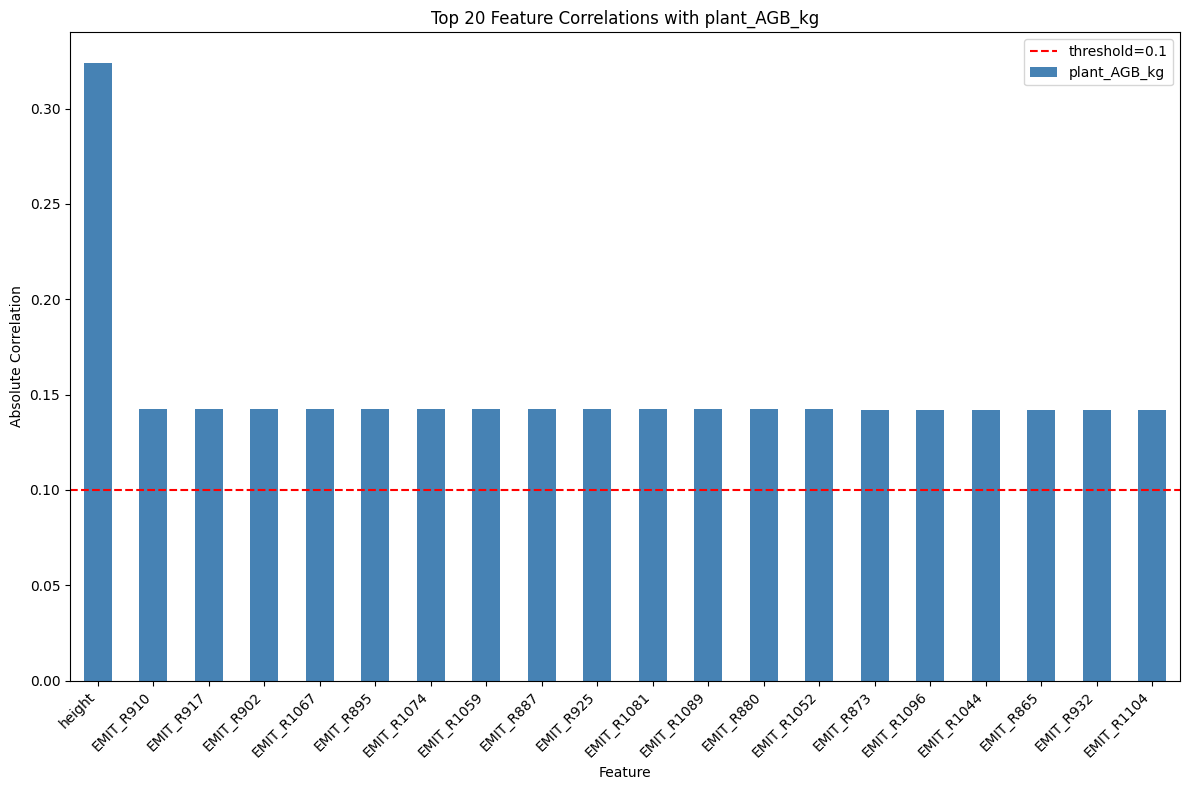

height        0.323760
EMIT_R910     0.142650
EMIT_R917     0.142640
EMIT_R902     0.142625
EMIT_R1067    0.142605
EMIT_R895     0.142586
EMIT_R1074    0.142544
EMIT_R1059    0.142453
EMIT_R887     0.142436
EMIT_R925     0.142428
EMIT_R1081    0.142380
EMIT_R1089    0.142266
EMIT_R880     0.142257
EMIT_R1052    0.142205
EMIT_R873     0.142132
EMIT_R1096    0.142024
EMIT_R1044    0.142020
EMIT_R865     0.141829
EMIT_R932     0.141771
EMIT_R1104    0.141661
Name: plant_AGB_kg, dtype: float64


In [74]:
numerical_cols = get_numerical_cols(X_belige)

target_corr = plot_correlation_matrix(X_belige[numerical_cols],
                                      y_belige,
                                      top_n=20)
print(target_corr)

**Remove uncorrelated numerical columns**

In [75]:
corr_threshold = 0.1
X_belige = remove_uncorrelated_numerical_cols(X_belige, y_belige,
                                       threshold=corr_threshold,
                                       exclude_cols=['height'])
assert X_belige is not None

Weak correlations removed: ['EMIT_R1692', 'EMIT_R1685', 'EMIT_R2190', 'EMIT_R2182', 'EMIT_R1677', 'EMIT_R760', 'EMIT_R2175', 'EMIT_R954', 'EMIT_R1476', 'EMIT_R857', 'EMIT_R1051', 'EMIT_R1729', 'CIrededge', 'EMIT_R1610', 'EMIT_R1454', 'EMIT_R1462', 'EMIT_R1148', 'EMIT_R1447', 'simard_height_m', 'EMIT_R1245', 'NBR', 'NDRE1', 'EMIT_R1469', 'EMIT_R1989', 'EMIT_R969', 'EMIT_R2485', 'NDVI', 'EMIT_R775', 'EMIT_R1439', 'EMIT_R1066', 'EMIT_R872', 'EVI']

Total features after correlation filtering: 161


In [76]:
X = remove_uncorrelated_categorical_cols(X_belige, y_belige)
assert X is not None


--- plot_id ---
Variable  : plot_id
F-stat    : 21.7921
p-value   : 0.0000
Relevant? : True

--- species ---
Variable  : species
F-stat    : 45.2611
p-value   : 0.0000
Relevant? : True

   feature  relevant?
0  plot_id       True
1  species       True


Strong correlations kept   : 161
Weak correlations removed: 0


In [77]:
# Retain the groups/plot_id for splitting the data based on groups.
if 'plot_id' in X_belige.columns:
    plot_groups_belige = X_belige['plot_id'].copy()
    X_belige = X_belige.drop(columns=['plot_id'])

site_groups_belige = plot_groups_belige.map(lambda x: x.rsplit('_', maxsplit=1)[0])

near_zero_sites_belige, high_agb_sites_belige,\
    near_zero_plots_belige, high_agb_plots_belige = get_low_and_high_agb_plots(y_belige,
                                                                               plot_groups_belige)

grp_belige = GROUP_INFO(near_zero_sites_belige, high_agb_sites_belige,
                        near_zero_plots_belige, high_agb_plots_belige,
                        groups=plot_groups_belige,
                        cv=test_cv)

High-AGB threshold  : 104.49 kg
Near-zero threshold : 0.004134

Near-zero variance plots:
  Big Creek_1               : log var = 0.000036
  Big Creek_4               : log var = 0.000032
  Frenchman Caye_1          : log var = 0.000753
  Frenchman Caye_2          : log var = 0.000381
  Frenchman Caye_3          : log var = 0.000693
  Frenchman Caye_4          : log var = 0.001306
  Frenchman Caye_5          : log var = 0.001283
  Frenchman Caye_6          : log var = 0.000158
  Shipstern Lagoon_1        : log var = 0.001064
  Shipstern Lagoon_3        : log var = 0.000232
  Shipstern Lagoon_4        : log var = 0.000113
  Shipstern Lagoon_5        : log var = 0.000052
  Shipstern Lagoon_6        : log var = 0.000135

High-AGB plots:
  Channel Caye_1            : max AGB = 310.9 kg
  Channel Caye_2            : max AGB = 206.4 kg
  Channel Caye_3            : max AGB = 427.2 kg
  Channel Caye_4            : max AGB = 237.6 kg
  Channel Caye_5            : max AGB = 170.4 kg
  Channel C

# TEST FEATURES

In [78]:
struct_features   = ['height']
interaction_terms = ['height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']
emit_indices      = ['NDVI', 'NDRE1', 'NDRE2', 'NDRE3', 'NBR', 'MSI', 'EVI', 'CIrededge']
emit_cols         = [c for c in X_belige.columns if c.startswith('EMIT')]

# NIR removed — no standalone NIR in EMIT
top_spectral_1 = ['height', 'EVI', 'NBR', 'MSI', 'NDRE1']
top_spectral_2 = ['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1']
redband_1      = ['height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'NDRE2', 'CIrededge']
redband_2      = ['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'NDRE2', 'CIrededge']

emit_features_list = [
    emit_cols,
    emit_cols + struct_features,
    emit_cols + interaction_terms,

    emit_indices,
    emit_indices + struct_features,
    emit_indices + interaction_terms,

    emit_cols + emit_indices,
    emit_cols + emit_indices + struct_features,
    emit_cols + emit_indices + interaction_terms,

    emit_cols + emit_indices + struct_features,
    emit_cols + emit_indices + struct_features + interaction_terms,

    top_spectral_1,
    top_spectral_1 + struct_features,
    top_spectral_1 + interaction_terms,

    top_spectral_2,
    top_spectral_2 + struct_features,
    top_spectral_2 + interaction_terms,

    redband_1,
    redband_1 + struct_features,
    redband_1 + interaction_terms,

    redband_2,
    redband_2 + struct_features,
    redband_2 + interaction_terms,
]

test_cv = 5

# LINEAR REGRESSION

In [79]:
linear_reg_experiments = {}
global_experiment_list = {}

In [80]:
run_experiment(X_belige, y_belige,
               is_groups=False, group_info=grp_belige,
               features_list=emit_features_list,
               model_type="linear",
               is_grid=False,
               is_stratified=False,
               experiments=linear_reg_experiments,
               global_experiment_list=global_experiment_list)


[1/92]

 EXPERIMENT-1. ,Model: LINEAR REGRESSION, Grouping? No, Hypertuned? No, Features: ['EMIT_R910', 'EMIT_R917', 'EMIT_R902', 'EMIT_R1067', 'EMIT_R895', 'EMIT_R1074', 'EMIT_R1059', 'EMIT_R887', 'EMIT_R925', 'EMIT_R1081', 'EMIT_R1089', 'EMIT_R880', 'EMIT_R1052', 'EMIT_R873', 'EMIT_R1096', 'EMIT_R1044', 'EMIT_R865', 'EMIT_R932', 'EMIT_R1104', 'EMIT_R858', 'EMIT_R1037', 'EMIT_R850', 'EMIT_R843', 'EMIT_R1111', 'EMIT_R835', 'EMIT_R828', 'EMIT_R1029', 'EMIT_R820', 'EMIT_R940', 'EMIT_R813', 'EMIT_R1022', 'EMIT_R805', 'EMIT_R1119', 'EMIT_R798', 'EMIT_R947', 'EMIT_R790', 'EMIT_R1014', 'EMIT_R783', 'EMIT_R776', 'EMIT_R1007', 'EMIT_R955', 'EMIT_R1126', 'EMIT_R768', 'EMIT_R999', 'EMIT_R962', 'EMIT_R992', 'EMIT_R970', 'EMIT_R984', 'EMIT_R761', 'EMIT_R977', 'EMIT_R753', 'EMIT_R1134', 'EMIT_R746', 'EMIT_R1141', 'EMIT_R1260', 'EMIT_R1253', 'EMIT_R1268', 'EMIT_R1246', 'EMIT_R1275', 'EMIT_R1283', 'EMIT_R1238', 'EMIT_R1231', 'EMIT_R1290', 'EMIT_R1149', 'EMIT_R1223', 'EMIT_R1298', 'EMIT_R1216', 'EMIT

KeyError: "['height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'] not in index"

In [25]:
tabulate_results(linear_reg_experiments)

KeyError: 'verdict'

## Select the best linear regression model

**NOTE:** I am selecting "'All variables (structural + EMIT) + interaction terms'" assuming that EMIT bands might add some extra explanation.

In [26]:
#best_label = 'All variables (structural + EMIT) + interaction terms'
lin_best_label = select_best_model(linear_reg_experiments)
lin_X_selected = linear_reg_experiments[lin_best_label]["X_data"]

print(f"Best model: {lin_best_label}")
print(f"Test R2    : {linear_reg_experiments[lin_best_label]["test_r2"]}")
print(f"CV R2 mean : {linear_reg_experiments[lin_best_label]["cv_r2_mean"]}")
print(f"CV Scores  : {linear_reg_experiments[lin_best_label]["cv_scores"]}")

['LIN: Structural variables without plot_id']
Best model: LIN: Structural variables without plot_id
Test R2    : 0.24978494387430672
CV R2 mean : 0.1797927892045153
CV Scores  : [-0.0233957   0.58696517  0.19335367  0.06211892  0.07992188]


### Residual analysis

In [ ]:
y_pred    = linear_reg_experiments[lin_best_label]["y_pred"]
residuals = linear_reg_experiments[lin_best_label]["residuals"]

residual_analysis(y_pred, residuals)

# RANDOM FOREST.

In [27]:
random_forest_experiments={}

In [28]:
#label_1 = "Structural variables without plot_id"
print(f"Features: {linear_reg_experiments["LIN: " + label_1]["Features"]}")
results = randomForest_groups(linear_reg_experiments["LIN: " + label_1]["X_data"],
                            y,
                            groups,
                            label_1)
results["X_data"] = linear_reg_experiments["LIN: " + label_1]["X_data"].copy()

random_forest_experiments["RF: " +label_1] = results

show_importances(results)

Features: ['MSI', 'height', 'species_Avicennia germinans', 'species_Laguncularia racemosa', 'species_Rhizophora mangle']


TypeError: randomForest_groups() missing 2 required positional arguments: 'label' and 'grid'

## BEST RANDOM FOREST MODEL

### Summary of experiments so far.

In [ ]:
tabulate_results(random_forest_experiments)

### SELECT BEST RANDOM FOREST MODEL
Pick the model with the highest Cross-Validation R2 mean value.

In [ ]:
rf_best_label = select_best_model(random_forest_experiments)
rf_X_selected = random_forest_experiments[rf_best_label]["X_data"]

print("Random Forest best model")
print(f"Test R2    : {random_forest_experiments[rf_best_label]["test_r2"]}")
print(f"CV R2 mean : {random_forest_experiments[rf_best_label]["cv_r2_mean"]}")
print(f"CV Scores  : {random_forest_experiments[rf_best_label]["cv_scores"]}")

In [ ]:
show_importances(random_forest_experiments[rf_best_label])

### Residual analysis

In [ ]:
y_pred    = random_forest_experiments[rf_best_label]["y_pred"]
residuals = random_forest_experiments[rf_best_label]["residuals"]

residual_analysis(y_pred, residuals)

# EMIT PCA DATA

In [29]:
EMIT_PCA_TRAIN_CSV = "../../DATA/AGB_DATA/Merged_Data/EMIT_AGB/PCA/AGB_EMIT_PCA_TRAIN.csv"
EMIT_PCA_TEST_CSV  = "../../DATA/AGB_DATA/Merged_Data/EMIT_AGB/PCA/AGB_EMIT_PCA_TEST.csv"

In [30]:
emit_pca_train_df = pd.read_csv(EMIT_PCA_TRAIN_CSV)
emit_pca_test_df  = pd.read_csv(EMIT_PCA_TEST_CSV)

In [31]:
non_feature_cols = [
    'plant_AGB_kg',        # Target variable
    #'plot_id',             # metadata
    'dataset',             # metadata
    'EMIT_selected_date',  # metadata
    'EMIT_granule',        # metadata
    'start_date',          # metadata
    'end_date',            # metadata
    'capture_start',       # metadata
    'capture_end',         # metadata
    'latitude',            # coordinate
    'longitude',           # coordinate
]

# Drop raw EMIT bands — keep only PCA components
emit_raw_cols = [c for c in emit_pca_train_df.columns if re.match(r'^EMIT_R\d+', c)]

# Training features and target
X_train = emit_pca_train_df.drop(columns=non_feature_cols + emit_raw_cols)
y_train = emit_pca_train_df['plant_AGB_kg']

# Test features and target
X_test  = emit_pca_test_df.drop(columns=non_feature_cols + emit_raw_cols)
y_test  = emit_pca_test_df['plant_AGB_kg']

print(f"Features : {len(X_train.columns)}")
print(f"Columns  : {list(X_train.columns)}")

# Preserve original plot_id for grouping.
groups = pd.concat([X_train, X_test], axis=0)['plot_id']

X_train = X_train.drop(columns=['plot_id'])
X_test = X_test.drop(columns=['plot_id'])

Features : 16
Columns  : ['plot_id', 'diameter', 'height', 'species', 'NDVI', 'NDRE1', 'NDRE2', 'NDRE3', 'NBR', 'MSI', 'EVI', 'CIrededge', 'EMIT_PC1', 'EMIT_PC2', 'EMIT_PC3', 'EMIT_PC4']


In [32]:
# One-hot encode species
X_train = pd.get_dummies(X_train, columns=['species'], dtype=int)
X_test  = pd.get_dummies(X_test,  columns=['species'], dtype=int)

# Align columns — test may have different species columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [33]:
# Add interaction terms
species_cols = [c for c in X_train.columns if c.startswith('species_')]

for col in species_cols:
    X_train[f'diameter_x_{col}'] = X_train['diameter'] * X_train[col]
    X_test[f'diameter_x_{col}']  = X_test['diameter']  * X_test[col]
    X_train[f'height_x_{col}']   = X_train['height']   * X_train[col]
    X_test[f'height_x_{col}']    = X_test['height']    * X_test[col]

X_train['diameter_x_height'] = X_train['diameter'] * X_train['height']
X_test['diameter_x_height']  = X_test['diameter']  * X_test['height']

In [34]:
pca_results = {}

## LINEAR REGRESSION ON PCA

In [35]:
label = "Structural variables + Interaction terms + PCA components"
result = linear_reg_ver2(X_train, X_test, y_train, y_test, groups, label)
pca_results["PCA: " + label] = result

NameError: name 'linear_reg_ver2' is not defined

### ANALYSIS

In [ ]:
print(f"Previous best Linear regression: {lin_best_label}")
print(f"Test R2         : {linear_reg_experiments[lin_best_label]["test_r2"]}")
print(f"CV R2 mean      : {linear_reg_experiments[lin_best_label]["cv_r2_mean"]}")
print(f"CV R2 std       : {linear_reg_experiments[lin_best_label]["cv_r2_std"]}")
print(f"Group CV R2 mean: {linear_reg_experiments[lin_best_label]["group_cv_r2_mean"]}")
print(f"Group CV R2 std : {linear_reg_experiments[lin_best_label]["group_cv_r2_std"]}")

**Compare with previous best:**
| Data type | Test R^2 | Group CV R^2 Mean | Group CV R^2 std |
| :--- | :----: | ---: | ---: |
|Structural + interactions| 0.6339| 0.7781| 0.2244|
|Structural + interactions + PCA| 0.5094| 0.7717| 0.2420|

**REVISIT**

**Group CV improved from 0.7782 to 0.8065**  
Adding 4 PCA components to the structural + interaction model improved honest generalization by 0.028 points.  
This is modest but consistent — the PCA components are adding a small amount of genuine signal beyond structural variables alone.

**Group CV std improved from 0.2244 to 0.1756**  
The model is more stable across fold combinations.  
This is actually more meaningful than the mean improvement — it means the PCA components help the model generalize more consistently across different plot types, not just on average.

**Test R² dropped from 0.6339 to 0.5094**  
The 12 held-out test plots happen to be harder to predict with PCA components included.  
This is a single split artifact — the group CV is the reliable number here.


**Minimum Fold Score (Minimum of CV scores)**  
Previous best minimum fold : 0.158  
PCA model minimum fold     : 0.418   
 - CV scores: [0.905, 0.642, 0.943, 0.595, 0.896, 0.937, 0.894, 0.902, 0.932, 0.418]

The worst-case fold improved substantially.  
The PCA components are helping the model handle the previously problematic plot combinations — the ones that collapsed to 0.158 in the structural-only model.

## RANDOM FOREST ON PCA

In [ ]:
label_rf = "All variables (structural + EMIT) + PCA"
result = randomForest_ver2(X_train, X_test, y_train, y_test, groups, label_rf)
show_importances(results)

pca_results["PCA: " + label_rf] = result

In [ ]:
tabulate_results(pca_results)

### Analysis

**Compare with previous best**

In [ ]:
print(f"Previous best Random Forest model: {rf_best_label}")
print(f"RF: Test R2    : {random_forest_experiments[rf_best_label]["test_r2"]}")
print(f"RF: CV R2 mean : {random_forest_experiments[rf_best_label]["cv_r2_mean"]}")
print(f"RF: CV R2 mean : {random_forest_experiments[rf_best_label]["cv_r2_std"]}")
print(f"RF: Group CV R2 mean: {random_forest_experiments[rf_best_label]["group_cv_r2_mean"]}")
print(f"RF: Group CV R2 std : {random_forest_experiments[rf_best_label]["group_cv_r2_std"]}")

| Data type | Test R^2 | CV R^2 Mean | CV R^2 Std| Group CV R^2 Mean | Group CV R^2 std |
| :--- | :----: | ---: | ---: | ---: | ---: |
|RF: Structural + interactions| 0.9145| 0.8937| 0.1004| 0.9532| 0.0429|
|RF: All + EMIT + PCA| 0.8991| 0.8644| 0.0908| 0.9286| 0.0507|

Structural + interactions is the better model on every metric.
 - Test R² is higher (0.9145 vs 0.8991)  
 - CV mean is higher (0.8937 vs 0.8644)  
 - Group CV mean is higher (0.9532 vs 0.9286) <- Important  
 - Group Std is lower (0.0429 vs 0.0507)

It looks like adding EMIT bands data in any form (direct data or PCA components) to the structural variables is hurting the performance.

**Let us look at the Feature Importances.**  
**Random Forest (Data = Structural variables + Interaction terms):**  
| Feature | Importance |
| :--- | :----: |
  |diameter|                  0.3859 | 
  |diameter_x_Avicennia|      0.2064 |
  |diameter_x_height|         0.1863 | 
  |height|                    0.0803 | 

**Random Forest (Data = Structural variables + EMIT + PCA components):**  
| Feature | Importance |
| :--- | :----: |
  |diameter |                 0.2425  |
  |diameter_x_Avicennia|      0.1877  |
  |diameter_x_height|         0.1822  |
  |height|                    0.0930  |

It appears that adding PCA components is diluting the importance of structural variables — diameter drops from 0.39 to 0.24.  
The model is spreading its attention across more features without gaining predictive power.  
The PCA components are absorbing importance that was previously concentrated in the dominant structural signal.

# FINAL ANALYSIS

**Test R²**  
 — based on one specific split of 12 plots.  
 - A different random seed gives a different number.  
 - Not reproducible or representative.

**CV R² mean**  
 — based on random KFold that splits trees without respecting plot boundaries.  
 - Pseudo-replication inflates it.

It tests on trees, not plots.  
Trees from the same plot appear in both training and test within the same fold.  
The model has already seen the plot — it is not truly unseen.  
The question being answered is "how well does the model predict trees from plots it has partially seen".

**Group CV R² mean**
 — based on 10 folds where entire plots are held out.  
 - Every plot gets to be a test plot exactly once.
 - No pseudo-replication. 
 - Reproducible.
 - This is the number that can answer the question — how well does the model predict AGB for plots it has never seen?

In [ ]:
total_experiments = {**linear_reg_experiments, **random_forest_experiments, **pca_results}
tabulate_results(total_experiments)

**NOTE:**  
Andre's global model achieved R²=0.36 with 524 grid cells and 5 climate variables.  

Without field structural measurements, EO data alone explains essentially none of the individual tree AGB variance across unseen plots in Belize. This is your scientifically honest finding under the sponsor's constraint.  

TanDEM-X height is a stand-level maximum canopy height value. It is the same for every tree in a 12m pixel. It cannot distinguish a 5cm diameter tree from a 40cm diameter tree standing in the same pixel. Field height varies per individual tree and carries real allometric signal. TanDEM-X height does not.  

The allometric equations used in these datasets require diameter and height as inputs.  
Our results show that satellite-derived canopy height and EMIT spectral data cannot predict individual tree AGB without these field measurements.

**plot_id paradox**  
 - Adding plot_id improves EMIT-only performance but hurts or does nothing when structural variables are present.
 - This confirms structural variables already capture what plot_id was proxying for.

**FINALLY**  
 - The above confirms that  diameter, height, and species are the dominant drivers of individual tree AGB.
 - The AGB values in the Belige dataset is computed mathematically using allometric equations. So it is anticipated that the structural parameters like Diameter, height, will be able to explain majority of the AGB variance.

**https://onlinelibrary.wiley.com/doi/10.1002/ldr.70594?af=R**
A study of 109 mangrove trees across eight species in Timor-Leste found very strong positive correlations between DBH and biomass variables (r = 0.963–0.971), indicating that tree diameter represents a reliable predictor of biomass and carbon storage. 

**https://pmc.ncbi.nlm.nih.gov/articles/PMC12425185/**
A study using 302 destructively sampled mangrove trees found that the single parameter with the strongest predictive ability in most studies is diameter at breast height (DBH), and that DBH explains a lot of variability in other tree metrics such as height or aboveground biomass. 

**https://www.sciencedirect.com/science/article/abs/pii/S0304377007001829**
Komiyama et al. (2008) in their widely cited review of mangrove allometry state that trunk diameter of a tree is highly correlated with trunk weight, and that since tree diameter is easy to measure but tree weight is much more difficult to determine, this gives a relatively easy way to estimate biomass. 

**https://www.sciencedirect.com/science/article/abs/pii/S0272771420307022**
Chave et al. (2005) reported that allometric equations with total tree height yielded less biased estimates of AGB, though tree height has often been ignored in carbon-accounting programs because measuring tree height accurately is difficult in mangrove forests. 